**Project: Pair Trading (Visa and Mastercard)**

By: Amani Narang

[*********************100%***********************]  2 of 2 completed


Historical Stock Prices:
                     V          MA
Date                              
2023-01-03  340.756561  203.156799
2023-01-04  348.961090  208.270233
2023-01-05  345.639954  206.800842
2023-01-06  361.849213  213.305344
2023-01-09  365.096924  214.137985




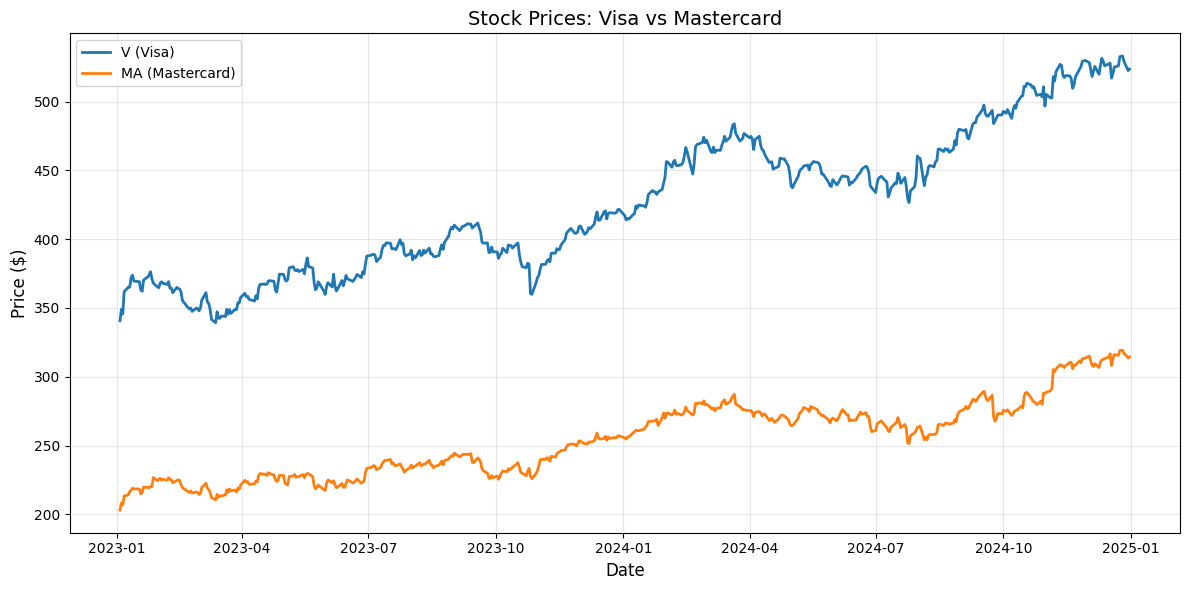

Correlation between V and MA returns: 0.7906


Price Spread (V - MA):
Date
2023-01-03    137.599762
2023-01-04    140.690857
2023-01-05    138.839111
2023-01-06    148.543869
2023-01-09    150.958939
dtype: float64


Spread Mean: $171.07
Spread Std Dev: $26.14




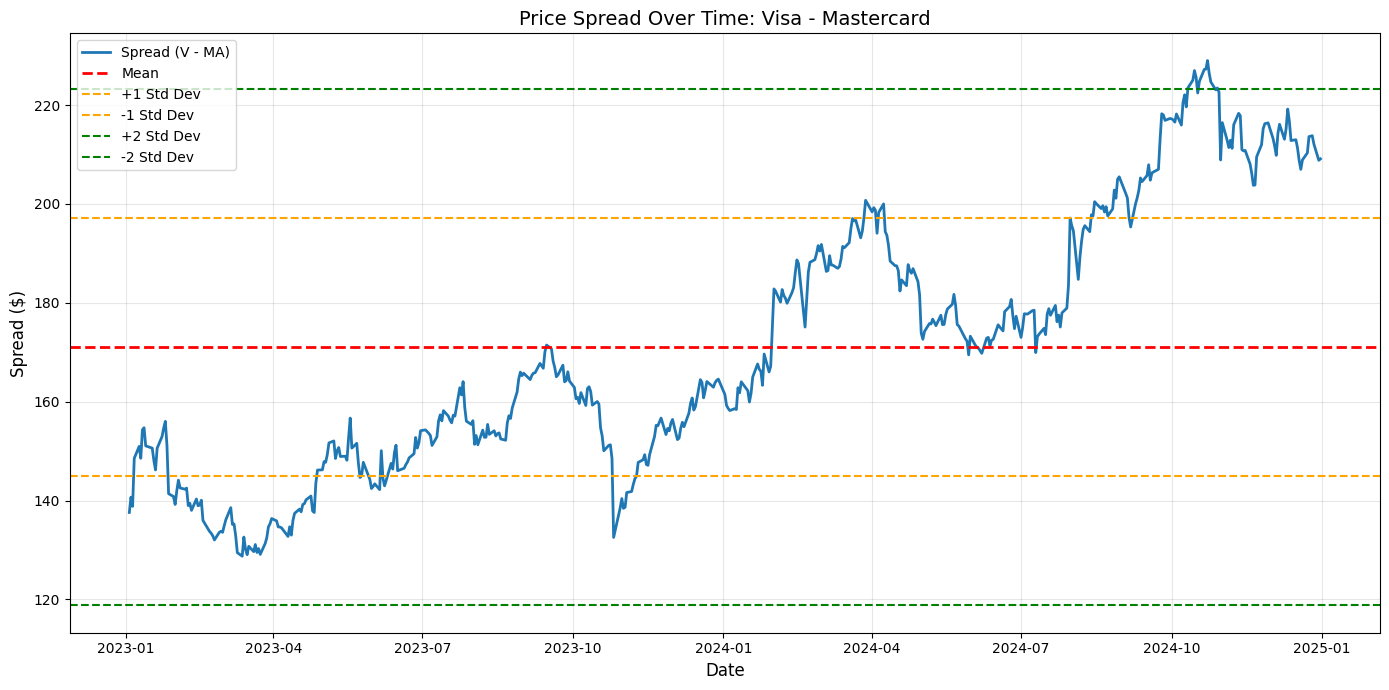

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Select Two Correlated Stocks
# Visa (V) and Mastercard (MA)

# Step 2: Download Historical Stock Data
ticker1 = 'V'
ticker2 = 'MA'

# Download data for 2 years
data = yf.download([ticker1, ticker2], start='2023-01-01', end='2025-01-01', auto_adjust=False)

# Extract adjusted close prices
if 'Adj Close' in data.columns.levels[0]:
    prices = data['Adj Close']
else:
    prices = data['Close']

prices.columns = [ticker1, ticker2]
print("Historical Stock Prices:")
print(prices.head())
print("\n")

# Plot both stock prices
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices[ticker1], label=f'{ticker1} (Visa)', linewidth=2)
plt.plot(prices.index, prices[ticker2], label=f'{ticker2} (Mastercard)', linewidth=2)
plt.title('Stock Prices: Visa vs Mastercard', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 3: Calculate Correlation Between the Stocks
returns = prices.pct_change().dropna()

correlation = returns[ticker1].corr(returns[ticker2])
print(f"Correlation between {ticker1} and {ticker2} returns: {correlation:.4f}")
print("\n")

# Step 4: Calculate the Price Spread
spread = prices[ticker1] - prices[ticker2]

print("Price Spread (V - MA):")
print(spread.head())
print("\n")

# Calculate spread statistics
spread_mean = spread.mean()
spread_std = spread.std()

print(f"Spread Mean: ${spread_mean:.2f}")
print(f"Spread Std Dev: ${spread_std:.2f}")
print("\n")

# Plot the spread with mean and standard deviation bands
plt.figure(figsize=(14, 7))
plt.plot(spread.index, spread, linewidth=2, label='Spread (V - MA)')

# Add mean line
plt.axhline(y=spread_mean, color='red', linestyle='--', linewidth=2, label=f'Mean')

# Add ±1 and ±2 standard deviation bands
plt.axhline(y=spread_mean + spread_std, color='orange', linestyle='--', linewidth=1.5, label=f'+1 Std Dev')
plt.axhline(y=spread_mean - spread_std, color='orange', linestyle='--', linewidth=1.5, label=f'-1 Std Dev')
plt.axhline(y=spread_mean + 2*spread_std, color='green', linestyle='--', linewidth=1.5, label=f'+2 Std Dev')
plt.axhline(y=spread_mean - 2*spread_std, color='green', linestyle='--', linewidth=1.5, label=f'-2 Std Dev')

plt.title('Price Spread Over Time: Visa - Mastercard', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Spread ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()